# Diffusion Policy on the Real PushT Dataset
**Lecture — Politecnico di Milano**

This notebook trains a **Diffusion Policy** on the real **PushT** demonstration dataset — a standard robot learning benchmark where a robot end-effector must push a T-shaped block to a target configuration.

**Dataset at** `data/pusht/` contains 206 expert demonstrations (~25 650 timesteps total):

| Array | Shape | Description |
|---|---|---|
| `data/state` | (25650, 5) | `[agent_x, agent_y, block_x, block_y, block_angle]` |
| `data/action` | (25650, 2) | `[target_x, target_y]` absolute target position |
| `meta/episode_ends` | (206,) | cumulative end index of each episode |

**What we build:**
- Observation $\mathbf{o}_t \in \mathbb{R}^4$: `[agent_x, agent_y, vx, vy]` (position + velocity)
- Action $\mathbf{a}_t \in \mathbb{R}^2$: `[dx, dy]` = `target - agent_pos` (delta target)
- Conditional 1D U-Net denoiser conditioned on $T_o = 2$ past observations
- Prediction horizon $T_p = 16$ action steps

In [1]:
import math, os, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


/home/vincenzopomponi/venvs/diffusion_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR   = 'data/pusht'      # path to the pusht zarr dataset
D_OBS      = 4                 # obs dim: [agent_x, agent_y, vx, vy]
D_ACTION   = 2                 # action dim: [dx, dy]
T_OBS      = 2                 # observation history length
T_PRED     = 16                # action prediction horizon
T_STEPS    = 100               # diffusion timesteps
BATCH_SIZE = 64
NUM_EPOCHS = 1200              # increase for better quality
LR         = 1e-3
SAVE_DIR   = 'pusht_results'
os.makedirs(SAVE_DIR, exist_ok=True)

---
## 1. Load the Dataset

The PushT dataset is stored in **Zarr format** (a chunked array format popular in robot learning). We use the `zarr` library to load the arrays directly into NumPy.

In [3]:
import zarr

data_grp  = zarr.open_group(os.path.join(DATA_DIR, 'data'), mode='r', zarr_format=2)
meta_grp  = zarr.open_group(os.path.join(DATA_DIR, 'meta'), mode='r', zarr_format=2)

raw_state        = data_grp['state'][:]          # (N, 5)  [ax, ay, bx, by, bangle]
raw_action       = data_grp['action'][:]         # (N, 2)  [target_x, target_y]
episode_ends     = meta_grp['episode_ends'][:]   # (206,)  cumulative end indices

N_TOTAL   = len(raw_state)
N_EP      = len(episode_ends)
ep_starts = np.concatenate([[0], episode_ends[:-1]])
ep_lens   = episode_ends - ep_starts

print(f'Total timesteps  : {N_TOTAL:,}')
print(f'Episodes         : {N_EP}')
print(f'Episode len stats: min={ep_lens.min()}, max={ep_lens.max()}, mean={ep_lens.mean():.0f}')
print(f'State  shape: {raw_state.shape}   columns: [agent_x, agent_y, block_x, block_y, block_angle]')
print(f'Action shape: {raw_action.shape}  columns: [target_x, target_y]')
print(f'\nState  range per col (min / max):')
for i, name in enumerate(['agent_x', 'agent_y', 'block_x', 'block_y', 'block_angle']):
    print(f'  {name:12s}: {raw_state[:,i].min():.1f} / {raw_state[:,i].max():.1f}')

Total timesteps  : 25,650
Episodes         : 206
Episode len stats: min=49, max=246, mean=125
State  shape: (25650, 5)   columns: [agent_x, agent_y, block_x, block_y, block_angle]
Action shape: (25650, 2)  columns: [target_x, target_y]

State  range per col (min / max):
  agent_x     : 13.5 / 496.1
  agent_y     : 32.9 / 511.0
  block_x     : 57.5 / 439.9
  block_y     : 108.3 / 485.7
  block_angle : 0.0 / 6.3


---
## 2. Feature Engineering

### Observation: `[agent_x, agent_y, vx, vy]`
- Position from `state[:, :2]`
- Velocity computed as finite differences: $v_t = s_t - s_{t-1}$ (clamped at episode boundaries)

### Action: `[dx, dy]`
- Delta target = `action - agent_pos`
- Represents: *how far from the current position should the robot move its target?*

In [4]:
# ── Compute velocity (zero at episode start) ─────────────────────────────────
agent_pos = raw_state[:, :2].copy()           # (N, 2)  pixel space
velocity  = np.zeros_like(agent_pos)          # (N, 2)

for start, end in zip(ep_starts, episode_ends):
    pos_ep = agent_pos[start:end]
    vel_ep = np.diff(pos_ep, axis=0, prepend=pos_ep[:1])   # zero at t=0
    velocity[start:end] = vel_ep

# ── Build obs and delta-action arrays ────────────────────────────────────────
obs_raw    = np.concatenate([agent_pos, velocity], axis=1)  # (N, 4)  [x, y, vx, vy]
action_raw = raw_action - agent_pos                         # (N, 2)  [dx, dy]

print('obs_raw    shape:', obs_raw.shape, '  [agent_x, agent_y, vx, vy]')
print('action_raw shape:', action_raw.shape, '  [dx, dy]')
print()
for i, name in enumerate(['agent_x', 'agent_y', 'vx', 'vy']):
    print(f'  obs  {name:8s}: mean={obs_raw[:,i].mean():7.2f}, std={obs_raw[:,i].std():6.2f},'
          f'  min={obs_raw[:,i].min():8.2f}, max={obs_raw[:,i].max():7.2f}')
print()
for i, name in enumerate(['dx', 'dy']):
    print(f'  act  {name:8s}: mean={action_raw[:,i].mean():7.2f}, std={action_raw[:,i].std():6.2f},'
          f'  min={action_raw[:,i].min():8.2f}, max={action_raw[:,i].max():7.2f}')

obs_raw    shape: (25650, 4)   [agent_x, agent_y, vx, vy]
action_raw shape: (25650, 2)   [dx, dy]

  obs  agent_x : mean= 229.11, std=101.85,  min=   13.46, max= 496.15
  obs  agent_y : mean= 293.31, std= 96.49,  min=   32.94, max= 510.96
  obs  vx      : mean=  -0.36, std=  8.09,  min=  -42.13, max=  59.12
  obs  vy      : mean=   0.28, std=  8.03,  min=  -44.94, max=  49.81

  act  dx      : mean=  -0.87, std= 20.19,  min= -114.04, max= 175.63
  act  dy      : mean=   0.68, std= 20.02,  min= -117.50, max= 141.32


In [5]:
# ── Normalisation statistics (computed over the full dataset) ─────────────────
obs_mean = obs_raw.mean(axis=0).astype(np.float32)   # (4,)
obs_std  = obs_raw.std(axis=0).astype(np.float32).clip(min=1e-3)
act_mean = action_raw.mean(axis=0).astype(np.float32) # (2,)
act_std  = action_raw.std(axis=0).astype(np.float32).clip(min=1e-3)

print('obs_mean:', obs_mean.round(2))
print('obs_std :', obs_std.round(2))
print('act_mean:', act_mean.round(2))
print('act_std :', act_std.round(2))

obs_mean: [ 2.2911e+02  2.9331e+02 -3.6000e-01  2.8000e-01]
obs_std : [101.85  96.49   8.09   8.03]
act_mean: [-0.87  0.68]
act_std : [20.19 20.02]


---
## 3. Dataset Visualisation

---
## 4. Dataset Class — Observation–Action Windows

For each timestep $t$ in an episode, we extract:
- **Observation**: last $T_o$ normalised states: shape `(T_obs, D_obs)`
- **Action chunk**: next $T_p$ normalised delta-actions: shape `(T_pred, D_action)`

Windows that would span an episode boundary are excluded.

In [6]:
class PushTDataset(Dataset):
    def __init__(self, obs_raw, action_raw, episode_ends,
                 obs_mean, obs_std, act_mean, act_std,
                 T_obs=2, T_pred=16):
        self.obs_n  = ((obs_raw  - obs_mean)  / obs_std ).astype(np.float32)
        self.act_n  = ((action_raw - act_mean) / act_std ).astype(np.float32)
        self.T_obs  = T_obs
        self.T_pred = T_pred

        # Build valid (obs_start, action_start) index pairs,
        # ensuring both windows lie within the same episode.
        ep_starts = np.concatenate([[0], episode_ends[:-1]])
        self.indices = []
        for s, e in zip(ep_starts, episode_ends):
            # obs window  : [t - T_obs, t)
            # action window: [t,        t + T_pred)
            for t in range(s + T_obs, e - T_pred + 1):
                self.indices.append((t - T_obs, t))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        obs_start, act_start = self.indices[idx]
        obs    = self.obs_n[obs_start : obs_start + self.T_obs]       # (T_obs,  D_obs)
        action = self.act_n[act_start : act_start + self.T_pred]      # (T_pred, D_action)
        return torch.from_numpy(obs), torch.from_numpy(action)

dataset = PushTDataset(obs_raw, action_raw, episode_ends,
                       obs_mean, obs_std, act_mean, act_std,
                       T_obs=T_OBS, T_pred=T_PRED)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                     num_workers=4, pin_memory=True)

obs_ex, act_ex = dataset[0]
print(f'Dataset windows        : {len(dataset):,}')
print(f'Observation shape      : {tuple(obs_ex.shape)}   (T_obs={T_OBS}, D_obs={D_OBS})')
print(f'Action chunk shape     : {tuple(act_ex.shape)}  (T_pred={T_PRED}, D_action={D_ACTION})')
print(f'Batches per epoch      : {len(loader)}')

Dataset windows        : 22,148
Observation shape      : (2, 4)   (T_obs=2, D_obs=4)
Action chunk shape     : (16, 2)  (T_pred=16, D_action=2)
Batches per epoch      : 347


---
## 5. Noise Schedule

In [7]:
def cosine_beta_schedule(T, s=0.008):
    steps  = torch.arange(T + 1, dtype=torch.float64)
    f      = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    a_bar  = f / f[0]
    betas  = torch.clamp(1.0 - a_bar[1:] / a_bar[:-1], 1e-5, 0.9999)
    return betas.float()

betas          = cosine_beta_schedule(T_STEPS).to(DEVICE)
alphas         = 1.0 - betas
a_bar          = torch.cumprod(alphas, dim=0)
a_bar_prev     = F.pad(a_bar[:-1], (1, 0), value=1.0)
sqrt_a_bar     = torch.sqrt(a_bar)
sqrt_one_minus = torch.sqrt(1.0 - a_bar)
sqrt_recip_a   = torch.sqrt(1.0 / alphas)
posterior_var  = (betas * (1.0 - a_bar_prev) / (1.0 - a_bar)).clamp(min=1e-20)

def q_sample(a0, t, noise=None):
    """Forward process: a_t = sqrt(a_bar_t)*a0 + sqrt(1-a_bar_t)*eps.
    a0: (B, D_action, T_pred),  t: (B,)
    """
    if noise is None:
        noise = torch.randn_like(a0)
    s = sqrt_a_bar[t].view(-1, 1, 1)
    n = sqrt_one_minus[t].view(-1, 1, 1)
    return s * a0 + n * noise, noise

print(f'Cosine schedule: T={T_STEPS}, beta range [{betas.min():.2e}, {betas.max():.4f}]')

Cosine schedule: T=100, beta range [6.31e-04, 0.9999]


---
## 6. Architecture — Conditional 1D U-Net

Same architecture as Notebook 06, conditioned on the observation via **FiLM** (Feature-wise Linear Modulation).

```
Obs (T_obs, D_obs)  →  MLP  ──────────────────────────────────────┐
Timestep k          →  SinEmb → MLP  ─────────────────────────────┤ concat → cond (B, cond_dim)
                                                                    │
Noisy action (D_a, T_pred)  →  1D U-Net blocks (FiLM conditioned) →  Predicted noise (D_a, T_pred)
```

In [8]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        f = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        x = t[:, None].float() * f[None, :]
        return torch.cat([x.sin(), x.cos()], dim=-1)

class CondResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim, kernel=5, dropout=0.05):
        super().__init__()
        pad = kernel // 2
        self.norm1  = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1  = nn.Conv1d(in_ch, out_ch, kernel, padding=pad)
        self.norm2  = nn.GroupNorm(min(8, out_ch), out_ch)
        self.drop   = nn.Dropout(dropout)
        self.conv2  = nn.Conv1d(out_ch, out_ch, kernel, padding=pad)
        self.res    = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.film   = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, out_ch * 2))
        self.act    = nn.SiLU()

    def forward(self, x, cond):
        h  = self.conv1(self.act(self.norm1(x)))
        ss = self.film(cond)
        scale, shift = ss.chunk(2, dim=1)
        h  = self.act(self.norm2(h)) * (1 + scale[:, :, None]) + shift[:, :, None]
        h  = self.conv2(self.drop(h))
        return h + self.res(x)

class DiffusionPolicy1D(nn.Module):
    """Conditional 1D U-Net — denoises action sequences given observations."""
    def __init__(self, d_action=2, d_obs=4, T_obs=2,
                 dim=128, t_emb_dim=128, obs_emb_dim=128):
        super().__init__()
        cond_dim = t_emb_dim + obs_emb_dim
        d, d2, d4 = dim, dim * 2, dim * 4

        self.time_emb = nn.Sequential(
            SinusoidalEmbedding(t_emb_dim),
            nn.Linear(t_emb_dim, t_emb_dim), nn.GELU(),
            nn.Linear(t_emb_dim, t_emb_dim)
        )
        self.obs_emb = nn.Sequential(
            nn.Linear(T_obs * d_obs, obs_emb_dim), nn.GELU(),
            nn.Linear(obs_emb_dim, obs_emb_dim)
        )

        self.inc  = nn.Conv1d(d_action, d, 3, padding=1)
        self.e1   = CondResBlock1D(d,   d,  cond_dim);  self.p1 = nn.MaxPool1d(2)
        self.e2   = CondResBlock1D(d,   d2, cond_dim);  self.p2 = nn.MaxPool1d(2)
        self.e3   = CondResBlock1D(d2,  d4, cond_dim)
        self.mid1 = CondResBlock1D(d4,  d4, cond_dim)
        self.mid2 = CondResBlock1D(d4,  d4, cond_dim)
        self.u3   = nn.ConvTranspose1d(d4, d4, 2, stride=2)
        self.d3   = CondResBlock1D(d4 + d2, d2, cond_dim)
        self.u2   = nn.ConvTranspose1d(d2, d2, 2, stride=2)
        self.d2   = CondResBlock1D(d2 + d,  d,  cond_dim)
        self.d1   = CondResBlock1D(d  + d,  d,  cond_dim)
        self.out  = nn.Sequential(
            nn.GroupNorm(min(8, d), d), nn.SiLU(),
            nn.Conv1d(d, d_action, 1)
        )

    def forward(self, noisy_action, obs, t):
        # noisy_action: (B, D_action, T_pred)
        # obs         : (B, T_obs, D_obs)
        # t           : (B,)
        t_emb  = self.time_emb(t)
        o_emb  = self.obs_emb(obs.flatten(1))
        cond   = torch.cat([t_emb, o_emb], dim=1)

        x0 = self.inc(noisy_action)
        x1 = self.e1(x0, cond);   x2 = self.e2(self.p1(x1), cond);  x3 = self.e3(self.p2(x2), cond)
        x3 = self.mid2(self.mid1(x3, cond), cond)
        h  = self.d3(torch.cat([self.u3(x3), x2], 1), cond)
        h  = self.d2(torch.cat([self.u2(h),  x1], 1), cond)
        h  = self.d1(torch.cat([h,            x0], 1), cond)
        return self.out(h)

model = DiffusionPolicy1D(
    d_action=D_ACTION, d_obs=D_OBS, T_obs=T_OBS, dim=128
).to(DEVICE)

# Sanity check
na = torch.randn(4, D_ACTION, T_PRED, device=DEVICE)
ob = torch.randn(4, T_OBS,   D_OBS,  device=DEVICE)
ts = torch.randint(0, T_STEPS, (4,),  device=DEVICE)
out = model(na, ob, ts)
print(f'Input  noisy action : {tuple(na.shape)}')
print(f'Input  observation  : {tuple(ob.shape)}')
print(f'Output              : {tuple(out.shape)}')
print(f'Total parameters    : {sum(p.numel() for p in model.parameters()):,}')

Input  noisy action : (4, 2, 16)
Input  observation  : (4, 2, 4)
Output              : (4, 2, 16)
Total parameters    : 12,166,018


---
## 7. Training

The loss is MSE between the true noise $\boldsymbol{\varepsilon}$ and the predicted noise $\boldsymbol{\varepsilon}_\theta(\mathbf{A}_k, \mathbf{O}, k)$:
$$\mathcal{L} = \mathbb{E}_{\mathbf{A}_0, k, \boldsymbol{\varepsilon}}\left[\|\boldsymbol{\varepsilon} - \boldsymbol{\varepsilon}_\theta(\mathbf{A}_k, \mathbf{O}, k)\|^2\right]$$

In [9]:
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Observation and action normalisation tensors on device
obs_mean_t = torch.from_numpy(obs_mean).to(DEVICE)
obs_std_t  = torch.from_numpy(obs_std).to(DEVICE)
act_mean_t = torch.from_numpy(act_mean).to(DEVICE)
act_std_t  = torch.from_numpy(act_std).to(DEVICE)

train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss = 0.0
    for obs_batch, act_batch in tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=False):
    # for obs_batch, act_batch in loader:
        # obs_batch: (B, T_obs, D_obs)   already normalised by dataset
        # act_batch: (B, T_pred, D_action) already normalised by dataset
        obs_b = obs_batch.to(DEVICE)
        act_b = act_batch.to(DEVICE).permute(0, 2, 1)  # → (B, D_action, T_pred)

        t     = torch.randint(0, T_STEPS, (act_b.size(0),), device=DEVICE)
        noise = torch.randn_like(act_b)
        noisy_act, _ = q_sample(act_b, t, noise)

        pred_noise = model(noisy_act, obs_b, t)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item()

    avg = ep_loss / len(loader)
    train_losses.append(avg)
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        ckpt = os.path.join(SAVE_DIR, f'ckpt_ep{epoch+1:04d}.pt')
        torch.save({'epoch': epoch+1, 'model': model.state_dict(),
                    'loss': avg, 'obs_mean': obs_mean, 'obs_std': obs_std,
                    'act_mean': act_mean, 'act_std': act_std}, ckpt)
        print(f'Epoch {epoch+1:4d}/{NUM_EPOCHS} | Loss: {avg:.5f} | Saved {ckpt}')

print('Training complete.')

Epoch   10/1200 | Loss: 0.18811 | Saved pusht_results/ckpt_ep0010.pt


Epoch   20/1200 | Loss: 0.18350 | Saved pusht_results/ckpt_ep0020.pt


Epoch   30/1200 | Loss: 0.17826 | Saved pusht_results/ckpt_ep0030.pt


Epoch   40/1200 | Loss: 0.17248 | Saved pusht_results/ckpt_ep0040.pt


Epoch   50/1200 | Loss: 0.16754 | Saved pusht_results/ckpt_ep0050.pt


...

Epoch 1160/1200 | Loss: 0.05397 | Saved pusht_results/ckpt_ep1160.pt


Epoch 1170/1200 | Loss: 0.05244 | Saved pusht_results/ckpt_ep1170.pt


Epoch 1180/1200 | Loss: 0.05296 | Saved pusht_results/ckpt_ep1180.pt


Epoch 1190/1200 | Loss: 0.05233 | Saved pusht_results/ckpt_ep1190.pt


Epoch 1200/1200 | Loss: 0.05275 | Saved pusht_results/ckpt_ep1200.pt
Training complete.


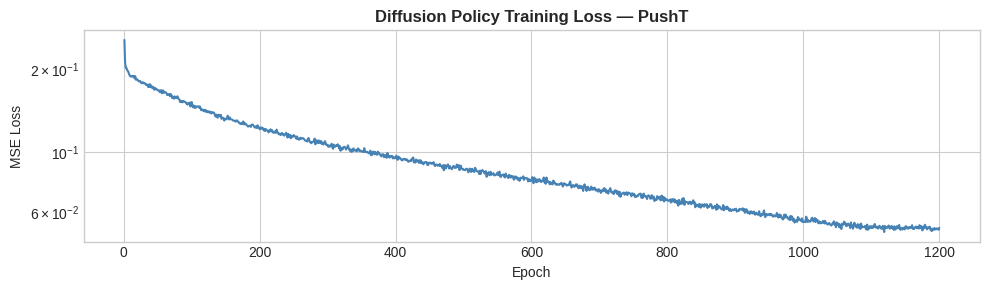

Final loss: 0.05275


In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, NUM_EPOCHS+1), train_losses, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Diffusion Policy Training Loss — PushT', fontsize=12, fontweight='bold')
ax.set_yscale('log')
plt.tight_layout()
plt.show()
print(f'Final loss: {train_losses[-1]:.5f}')

---
## 8. Inference — DDPM Sampler

Given an observation $\mathbf{O}$, generate $N$ action chunk samples by running the full reverse process.

In [11]:
@torch.no_grad()
def sample_actions_ddpm(obs_raw_window, n_samples=10):
    """DDPM sampler.
    obs_raw_window: (T_obs, D_obs) numpy array in raw (unnormalised) space.
    Returns: (n_samples, T_pred, D_action) numpy array in raw pixel-delta space.
    """
    model.eval()
    obs_n   = (obs_raw_window - obs_mean) / obs_std       # normalise
    obs_t   = torch.from_numpy(obs_n).float().to(DEVICE)
    obs_in  = obs_t.unsqueeze(0).repeat(n_samples, 1, 1)  # (n, T_obs, D_obs)

    x = torch.randn(n_samples, D_ACTION, T_PRED, device=DEVICE)

    for t_idx in reversed(range(T_STEPS)):
        t_b    = torch.full((n_samples,), t_idx, device=DEVICE, dtype=torch.long)
        eps    = model(x, obs_in, t_b)
        coeff  = betas[t_idx] / sqrt_one_minus[t_idx]
        mean   = sqrt_recip_a[t_idx] * (x - coeff * eps)
        if t_idx > 0:
            x  = mean + torch.sqrt(posterior_var[t_idx]) * torch.randn_like(x)
        else:
            x  = mean

    # Denormalise: (n, D_action, T_pred) → (n, T_pred, D_action)
    actions_n = x.permute(0, 2, 1).cpu().numpy()
    return actions_n * act_std + act_mean   # back to pixel-delta space


@torch.no_grad()
def sample_actions_ddim(obs_raw_window, n_samples=10, ddim_steps=10):
    """DDIM sampler (faster inference)."""
    model.eval()
    obs_n   = (obs_raw_window - obs_mean) / obs_std
    obs_t   = torch.from_numpy(obs_n).float().to(DEVICE)
    obs_in  = obs_t.unsqueeze(0).repeat(n_samples, 1, 1)

    tau  = torch.linspace(0, T_STEPS - 1, ddim_steps + 1).long().flip(0)
    x    = torch.randn(n_samples, D_ACTION, T_PRED, device=DEVICE)

    for i in range(len(tau) - 1):
        t_cur  = int(tau[i]);  t_prev = int(tau[i + 1])
        t_b    = torch.full((n_samples,), t_cur, device=DEVICE, dtype=torch.long)
        eps    = model(x, obs_in, t_b)
        ab_i   = a_bar[t_cur];  ab_p = a_bar[t_prev]
        x0_hat = ((x - torch.sqrt(1 - ab_i) * eps) / torch.sqrt(ab_i)).clamp(-5, 5)
        x      = torch.sqrt(ab_p) * x0_hat + torch.sqrt(1 - ab_p) * eps

    actions_n = x.permute(0, 2, 1).cpu().numpy()
    return actions_n * act_std + act_mean

print('Samplers defined.')

Samplers defined.


---
## 9. Visualise Generated Action Sequences

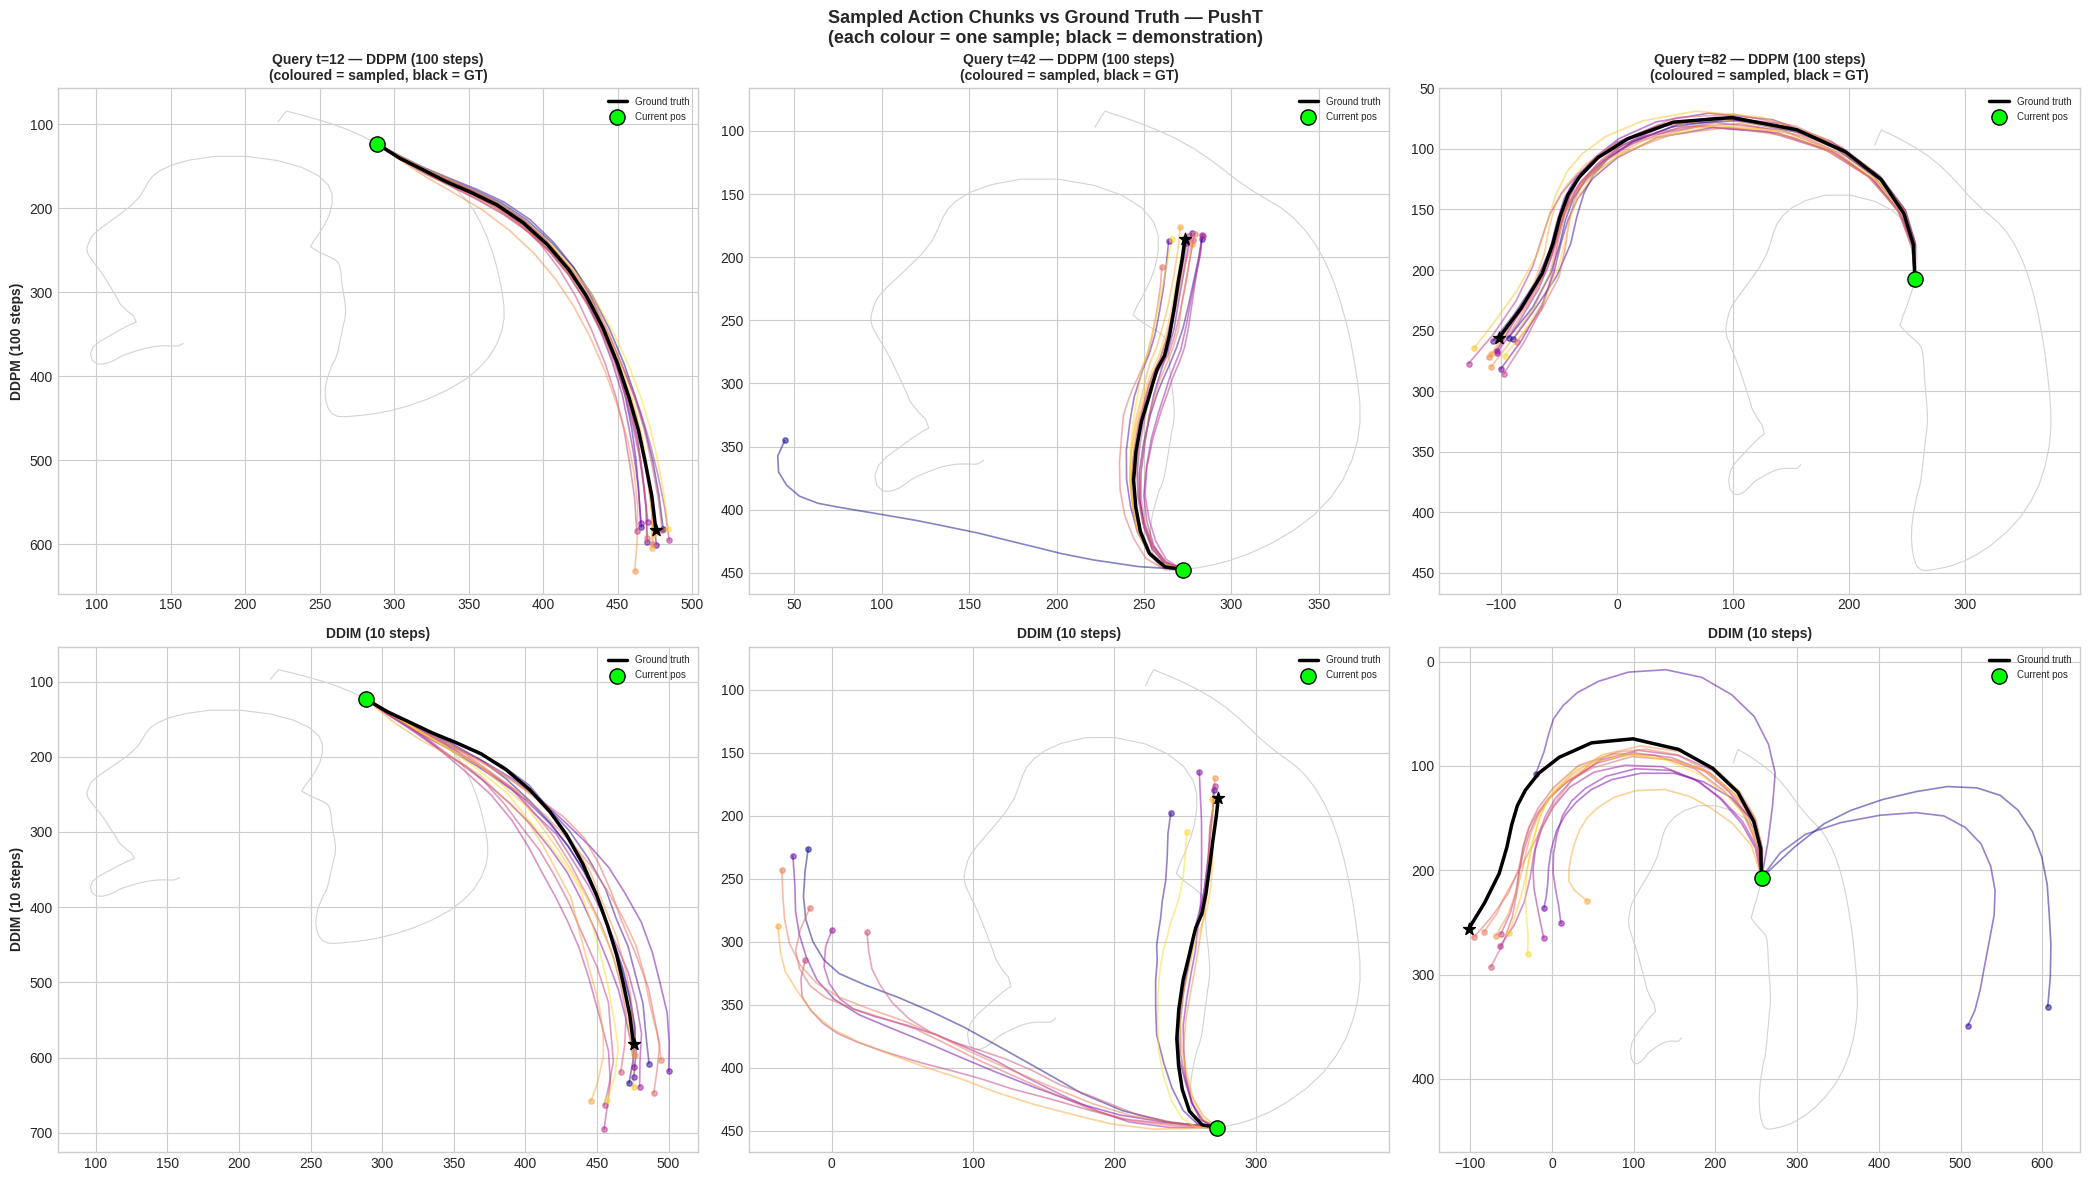

In [12]:
# Pick 3 real observation windows from the dataset and sample actions
def get_obs_window(timestep_idx):
    """Return obs_raw window ending just before timestep_idx."""
    start = timestep_idx - T_OBS
    pos   = agent_pos[start:timestep_idx]           # (T_obs, 2)
    vel   = velocity[start:timestep_idx]            # (T_obs, 2)
    return np.concatenate([pos, vel], axis=1)       # (T_obs, 4)

def get_gt_action_chunk(timestep_idx):
    """Ground-truth delta-action chunk starting at timestep_idx."""
    return action_raw[timestep_idx:timestep_idx + T_PRED]  # (T_pred, 2)

# Use three different starting points from episode 0
ep0_start, ep0_end = ep_starts[0], episode_ends[0]
test_points = [ep0_start + T_OBS + 10,
               ep0_start + T_OBS + 40,
               ep0_start + T_OBS + 80]
test_points = [t for t in test_points if t + T_PRED <= ep0_end]

fig, axes = plt.subplots(2, len(test_points), figsize=(7 * len(test_points), 12),
                          squeeze=False)

for col, t_start in enumerate(test_points):
    obs_win = get_obs_window(t_start)
    gt_act  = get_gt_action_chunk(t_start)
    cur_pos = agent_pos[t_start - 1]                  # current agent position

    # Sample with DDPM
    samples_ddpm = sample_actions_ddpm(obs_win, n_samples=15)
    # Sample with DDIM
    samples_ddim = sample_actions_ddim(obs_win, n_samples=15, ddim_steps=10)

    for row, (samples, sampler_name) in enumerate([
            (samples_ddpm, f'DDPM ({T_STEPS} steps)'),
            (samples_ddim, 'DDIM (10 steps)')]):
        ax = axes[row, col]

        # Draw the episode background trajectory (light grey)
        bg = agent_pos[ep0_start:ep0_end]
        ax.plot(bg[:, 0], bg[:, 1], color='lightgrey', linewidth=0.8, zorder=1)

        # Draw sampled action chunks (delta → absolute positions)
        for s_idx, sample in enumerate(samples):
            # Reconstruct absolute positions: pos[t] = pos[t-1] + delta[t]
            positions = np.zeros((T_PRED + 1, 2))
            positions[0] = cur_pos
            for step in range(T_PRED):
                positions[step + 1] = positions[step] + sample[step]
            color = cm.plasma(s_idx / len(samples))
            ax.plot(positions[:, 0], positions[:, 1],
                    alpha=0.5, linewidth=1.2, color=color, zorder=3)
            ax.scatter(positions[-1, 0], positions[-1, 1],
                       s=15, color=color, alpha=0.5, zorder=4)

        # Draw ground-truth action chunk
        gt_positions = np.zeros((T_PRED + 1, 2))
        gt_positions[0] = cur_pos
        for step in range(T_PRED):
            gt_positions[step + 1] = gt_positions[step] + gt_act[step]
        ax.plot(gt_positions[:, 0], gt_positions[:, 1],
                'k-', linewidth=2.5, zorder=5, label='Ground truth')
        ax.scatter(gt_positions[-1, 0], gt_positions[-1, 1],
                   c='black', s=80, marker='*', zorder=6)

        # Mark current agent position
        ax.scatter(cur_pos[0], cur_pos[1], c='lime', s=120,
                   edgecolors='black', linewidths=1, zorder=7, label='Current pos')

        # ax.set_xlim(0, 512); ax.set_ylim(0, 512)
        ax.invert_yaxis()
        if row == 0:
            ax.set_title(f'Query t={t_start} — {sampler_name}\n(coloured = sampled, black = GT)',
                         fontsize=10, fontweight='bold')
        else:
            ax.set_title(sampler_name, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(sampler_name, fontsize=10, fontweight='bold', rotation=90)
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Sampled Action Chunks vs Ground Truth — PushT\n'
             '(each colour = one sample; black = demonstration)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# ── DDPM vs DDIM speed comparison ────────────────────────────────────────────
obs_win = get_obs_window(test_points[0])

torch.manual_seed(0)
t0 = time.time()
_ = sample_actions_ddpm(obs_win, n_samples=10)
time_ddpm = time.time() - t0

torch.manual_seed(0)
t0 = time.time()
_ = sample_actions_ddim(obs_win, n_samples=10, ddim_steps=10)
time_ddim = time.time() - t0

print(f'DDPM ({T_STEPS} steps) : {time_ddpm:.3f}s per query')
print(f'DDIM (10  steps) : {time_ddim:.3f}s per query')
print(f'Speedup          : {time_ddpm / time_ddim:.1f}×')
print()
print('For real-time robot control (e.g. 10 Hz):')
print(f'  Available time per query : 100 ms')
print(f'  DDPM feasible            : {"Yes" if time_ddpm < 0.1 else "No (too slow)"}')
print(f'  DDIM feasible            : {"Yes" if time_ddim < 0.1 else "No (too slow)"}')

DDPM (100 steps) : 0.341s per query
DDIM (10  steps) : 0.032s per query
Speedup          : 10.5×

For real-time robot control (e.g. 10 Hz):
  Available time per query : 100 ms
  DDPM feasible            : No (too slow)
  DDIM feasible            : Yes


---
## 10. Action Distribution Analysis

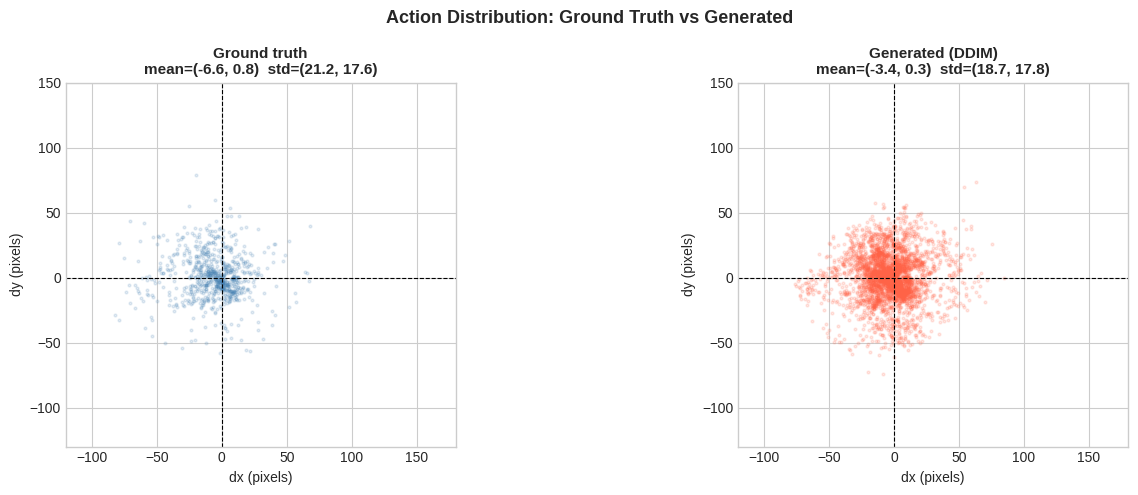

In [14]:
# Sample a large batch of actions from multiple observations and compare
# their distribution to the real dataset
rng_indices = np.random.choice(
    [t for t in range(T_OBS, len(obs_raw) - T_PRED) if True],
    size=200, replace=False
)

all_sampled, all_gt = [], []
for t_idx in rng_indices[:50]:   # limit to 50 for speed
    obs_win = get_obs_window(t_idx)
    sampled = sample_actions_ddim(obs_win, n_samples=5, ddim_steps=10)
    gt      = get_gt_action_chunk(t_idx)
    all_sampled.append(sampled.reshape(-1, D_ACTION))
    all_gt.append(gt)

all_sampled = np.concatenate(all_sampled, axis=0)
all_gt      = np.concatenate(all_gt, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color in [
        (axes[0], all_gt,      'Ground truth',   'steelblue'),
        (axes[1], all_sampled, 'Generated (DDIM)', 'tomato')]:
    ax.scatter(data[:, 0], data[:, 1], alpha=0.15, s=4, color=color)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlim(-120, 180); ax.set_ylim(-130, 150)
    ax.set_title(f'{label}\nmean=({data[:,0].mean():.1f}, {data[:,1].mean():.1f})  '
                 f'std=({data[:,0].std():.1f}, {data[:,1].std():.1f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('dx (pixels)'); ax.set_ylabel('dy (pixels)')
    ax.set_aspect('equal')

plt.suptitle('Action Distribution: Ground Truth vs Generated', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Load a Saved Checkpoint

If you want to skip training and load a pre-trained checkpoint:

In [15]:
def load_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    model.eval()
    # Restore normalisation stats from checkpoint
    global obs_mean, obs_std, act_mean, act_std
    obs_mean = ckpt['obs_mean']
    obs_std  = ckpt['obs_std']
    act_mean = ckpt['act_mean']
    act_std  = ckpt['act_std']
    print(f'Loaded checkpoint: epoch={ckpt["epoch"]}, loss={ckpt["loss"]:.5f}')

# Uncomment to load:
# load_checkpoint('pusht_results/ckpt_ep0100.pt')

# List available checkpoints
ckpts = sorted([f for f in os.listdir(SAVE_DIR) if f.endswith('.pt')])
if ckpts:
    print('Available checkpoints:')
    for c in ckpts:
        print(f'  {c}')
else:
    print('No checkpoints found. Run training first.')

Available checkpoints:
  ckpt_ep0010.pt
  ckpt_ep0020.pt
  ckpt_ep0030.pt
  ckpt_ep0040.pt
  ckpt_ep0050.pt
  ckpt_ep0060.pt
  ckpt_ep0070.pt
  ckpt_ep0080.pt
  ckpt_ep0090.pt
  ckpt_ep0100.pt
  ckpt_ep0110.pt
  ckpt_ep0120.pt
  ckpt_ep0130.pt
  ckpt_ep0140.pt
  ckpt_ep0150.pt
  ckpt_ep0160.pt
  ckpt_ep0170.pt
  ckpt_ep0180.pt
  ckpt_ep0190.pt
  ckpt_ep0200.pt
  ckpt_ep0210.pt
  ckpt_ep0220.pt
  ckpt_ep0230.pt
  ckpt_ep0240.pt
  ckpt_ep0250.pt
  ckpt_ep0260.pt
  ckpt_ep0270.pt
  ckpt_ep0280.pt
  ckpt_ep0290.pt
  ckpt_ep0300.pt
  ckpt_ep0310.pt
  ckpt_ep0320.pt
  ckpt_ep0330.pt
  ckpt_ep0340.pt
  ckpt_ep0350.pt
  ckpt_ep0360.pt
  ckpt_ep0370.pt
  ckpt_ep0380.pt
  ckpt_ep0390.pt
  ckpt_ep0400.pt
  ckpt_ep0410.pt
  ckpt_ep0420.pt
  ckpt_ep0430.pt
  ckpt_ep0440.pt
  ckpt_ep0450.pt
  ckpt_ep0460.pt
  ckpt_ep0470.pt
  ckpt_ep0480.pt
  ckpt_ep0490.pt
  ckpt_ep0500.pt
  ckpt_ep0510.pt
  ckpt_ep0520.pt
  ckpt_ep0530.pt
  ckpt_ep0540.pt
  ckpt_ep0550.pt
  ckpt_ep0560.pt
  ckpt_ep0570.pt
  ckpt_e

---
## Summary

### Dataset
| Array | Shape | Description |
|---|---|---|
| `data/state` | (25650, 5) | `[agent_x, agent_y, block_x, block_y, block_angle]` |
| `data/action` | (25650, 2) | absolute target `[x, y]` |
| `meta/episode_ends` | (206,) | episode boundary indices |

### Feature Engineering
| Feature | Formula | Dim |
|---|---|---|
| Observation | `[agent_x, agent_y, vx, vy]` | 4 |
| Action (delta) | `target - agent_pos` | 2 |

### Model
| Component | Detail |
|---|---|
| Architecture | Conditional 1D U-Net |
| Conditioning | FiLM (time + observation → scale/shift) |
| Channels | 128 → 256 → 512 |
| Diffusion steps | T = 100 (cosine schedule) |
| Inference | DDPM (100 steps) or DDIM (10 steps) |

### Tips for improvement
- Include **block state** `[block_x, block_y, block_angle]` in the observation → $D_o = 7$
- Use a **longer observation window** ($T_o = 4$) for better temporal context
- Add **visual observations** by encoding the `img` array with a CNN
- Use **transformer** backbone instead of 1D U-Net for longer horizons